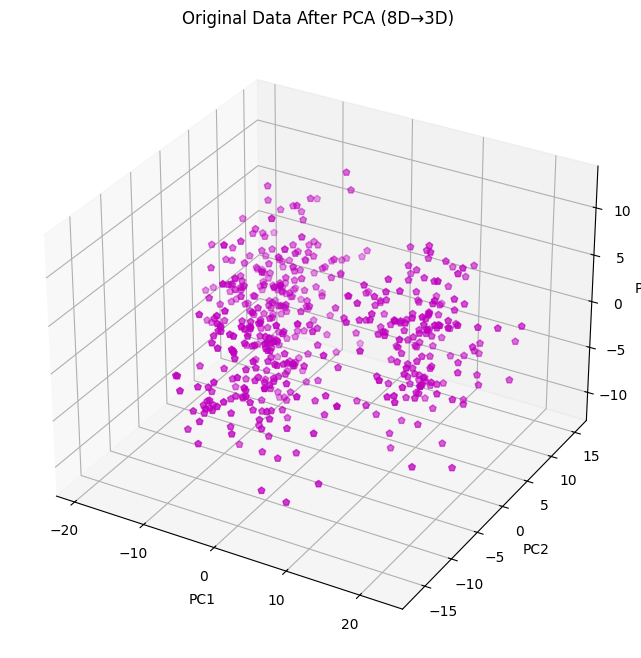

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import make_blobs
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import fowlkes_mallows_score, rand_score, davies_bouldin_score

# ===================== 1. 生成数据集 =====================
X, y = make_blobs(
    n_samples=500,
    n_features=8,
    centers=3,
    cluster_std=4.0,
    random_state=3
)

# ===================== 2. PCA降维（8D→3D） =====================
pca = PCA(n_components=3)
X_rd = pca.fit_transform(X)

# 绘制降维后原始数据 3D 图
fig1 = plt.figure(figsize=(10, 8))
ax1 = fig1.add_subplot(111, projection='3d')
ax1.scatter(X_rd[:, 0], X_rd[:, 1], X_rd[:, 2], s=25, c='m', marker='p')
ax1.set_title('Original Data After PCA (8D→3D)')
ax1.set_xlabel('PC1')
ax1.set_ylabel('PC2')
ax1.set_zlabel('PC3')
plt.show()


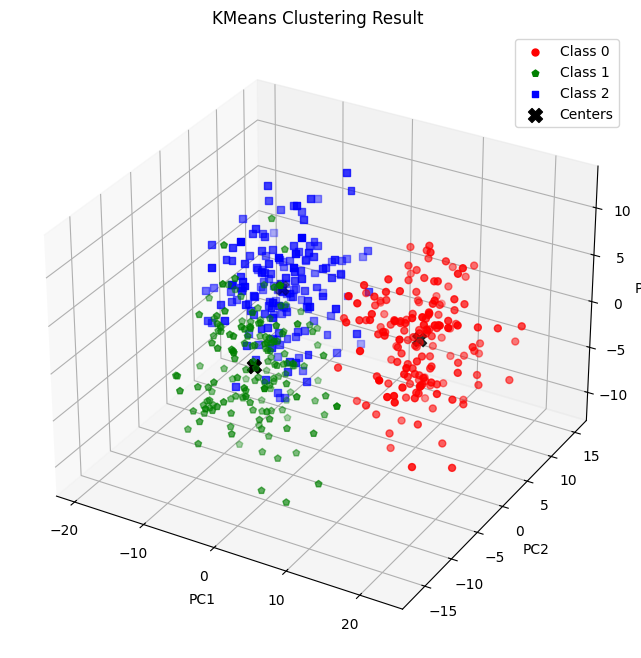

In [5]:
# ===================== 3. KMeans 聚类 =====================
kmeans_model = KMeans(n_clusters=3, init='random', n_init=1, random_state=3)
kmeans_model.fit(X_rd)
y_kmeans = kmeans_model.labels_
centers = kmeans_model.cluster_centers_

# KMeans 3D可视化
fig2 = plt.figure(figsize=(10, 8))
ax2 = fig2.add_subplot(111, projection='3d')

# 按类别分别画点（红、绿、蓝）
class0 = np.where(y_kmeans == 0)
class1 = np.where(y_kmeans == 1)
class2 = np.where(y_kmeans == 2)

ax2.scatter(X_rd[class0, 0], X_rd[class0, 1], X_rd[class0, 2], c='r', marker='o', s=25)
ax2.scatter(X_rd[class1, 0], X_rd[class1, 1], X_rd[class1, 2], c='g', marker='p', s=25)
ax2.scatter(X_rd[class2, 0], X_rd[class2, 1], X_rd[class2, 2], c='b', marker='s', s=25)
# 聚类中心（黑色X）
ax2.scatter(centers[:, 0], centers[:, 1], centers[:, 2], c='k', marker='X', s=100)

ax2.set_title('KMeans Clustering Result')
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.set_zlabel('PC3')
ax2.legend(['Class 0', 'Class 1', 'Class 2', 'Centers'])
plt.show()

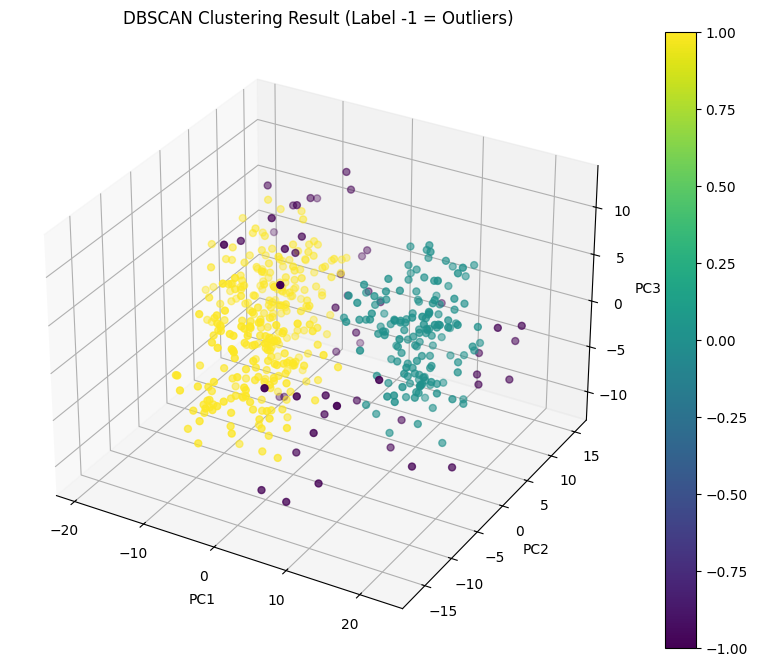

========== KMeans 聚类评估 ==========
FMI Score: 0.9606797574061148
Rand Index: 0.9738837675350701
DB Index: 0.8034196210442346

========== DBSCAN 聚类评估 ==========
FMI Score: 0.6934787671207157
Rand Index: 0.7531703406813627
DB Index: 2.3825954734129495


In [7]:

# ===================== 4. DBSCAN 聚类 ===================== #  
dbscan_model = DBSCAN(eps=4, min_samples=10, metric='euclidean')
dbscan_model.fit(X_rd)
y_dbscan = dbscan_model.labels_

# DBSCAN 3D可视化
fig3 = plt.figure(figsize=(10, 8))
ax3 = fig3.add_subplot(111, projection='3d')
sc = ax3.scatter(X_rd[:, 0], X_rd[:, 1], X_rd[:, 2], c=y_dbscan, cmap='viridis', s=25)

ax3.set_title('DBSCAN Clustering Result (Label -1 = Outliers)')
ax3.set_xlabel('PC1')
ax3.set_ylabel('PC2')
ax3.set_zlabel('PC3')
plt.colorbar(sc)
plt.show()

# ===================== 5. 聚类性能评估 =====================
print("========== KMeans 聚类评估 ==========")
print("FMI Score:", fowlkes_mallows_score(y, y_kmeans))
print("Rand Index:", rand_score(y, y_kmeans))
print("DB Index:", davies_bouldin_score(X_rd, y_kmeans))

print("\n========== DBSCAN 聚类评估 ==========")
print("FMI Score:", fowlkes_mallows_score(y, y_dbscan))
print("Rand Index:", rand_score(y, y_dbscan))
print("DB Index:", davies_bouldin_score(X_rd, y_dbscan))